In [ ]:
# ====================================================================
# 1. IMPORTS & CONFIGURATION
# ====================================================================
import os
import glob
import re
import random
import joblib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_curve

from xgboost import XGBClassifier
from tensorflow.keras.models import load_model

import warnings
warnings.filterwarnings('ignore')

class Config:
    # --- PATHS ---
    DATA_DIR = "./data/" 
    
    # Helper Models
    ISO_MODEL_PATH = './../models/IsolationForest/model/iso_model2.joblib'
    ISO_SCALER_PATH = './../models/IsolationForest/model/iso_scaler2.joblib'
    LSTM_MODEL_PATH = './../models/LSTM_Autoencoders/lstm_autoencoder_model_fit.h5'
    LSTM_SCALER_PATH = './../models/LSTM_Autoencoders/scaler_fit.save'
    
    # Outputs
    OUTPUT_MODEL = "./model/ultimate_xgboost_model.json"
    OUTPUT_SCALER = "./model/ultimate_xgboost_scaler.save"
    OUTPUT_SELECTOR = "./model/ultimate_feature_selector.save" # เก็บตัวเลือกฟีเจอร์
    
    # --- SETTINGS ---
    SEQUENCE_LENGTH = 30
    TEST_KEYWORDS = ['label_for_dev109_test_prepared'] 
    OVERSAMPLE_TARGET = 5000
    VAL_SPLIT_RATIO = 0.2
    
    # RFE Settings (เลือกกี่ฟีเจอร์)
    N_FEATURES_TO_SELECT = 50 
    
    RAW_COLS = ['rain', 'soil', 'temp', 'humi', 'geo']
    LABEL_COL = 'label'
    LABEL_MAP = {'normal': 0, 'warning': 1, 'critical': 2}
    
    # Weights
    SAMPLE_WEIGHTS = {0: 1.0, 1: 2.0, 2: 3.0}
    
    # Grid Search
    PARAM_GRID = {
        'n_estimators': [100, 200, 300, 400],    
        'learning_rate': [0.01, 0.05, 0.1],     
        'max_depth': [4, 6, 8],    
        'subsample': [0.7, 0.8],    
        'colsample_bytree': [0.7, 0.8],
        'min_child_weight': [1, 5, 10],   
        'gamma': [0, 0.2, 0.5],   
    }
    
    XGB_FIXED = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'n_jobs': -1,
        'random_state': 42,
        'tree_method': 'hist'
    }

cfg = Config()
np.random.seed(42); random.seed(42)

def log(msg): print(f"[INFO] {time.strftime('%H:%M:%S')} - {msg}")
print("✅ Config Loaded (Ultimate Version)")

✅ Config Loaded (Ultimate Version)


In [14]:
# ====================================================================
# 2. LOAD & FEATURE ENGINEERING (Standard)
# ====================================================================
# (ส่วนนี้เหมือนเดิม ย่อเพื่อความกระชับ แต่ทำงานครบถ้วน)

def load_and_split_data():
    log("Scanning files...")
    train_dfs, test_dfs = [], []
    for f_path in glob.glob(os.path.join(cfg.DATA_DIR, "*.csv")):
        filename = os.path.basename(f_path)
        is_test = any(k in filename for k in cfg.TEST_KEYWORDS)
        target_list = test_dfs if is_test else train_dfs
        try:
            df = pd.read_csv(f_path)
            df.columns = [str(c).lower().strip().replace('.1', '') for c in df.columns]
            rename_map = {'temperature':'temp', 'hum':'humi', 'humidity':'humi', 'devid':'devID', 'time':'timestamp', 'date':'timestamp'}
            new_cols = {c: rename_map[c] for c in df.columns if c in rename_map}
            if new_cols: df = df.rename(columns=new_cols)
            if 'devID' in df.columns: df['devID'] = df['devID'].astype(str).apply(lambda x: int(re.search(r'(\d+)', x).group(1)) if re.search(r'(\d+)', x) else 0)
            if 'timestamp' in df.columns: df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
            for c in cfg.RAW_COLS: 
                if c not in df.columns: df[c] = 0.0
            target_list.append(df)
            print(f"   -> {filename} [{'TEST' if is_test else 'TRAIN'}]")
        except: pass
    if not train_dfs: raise ValueError("No Train Data")
    return pd.concat(train_dfs, ignore_index=True), (pd.concat(test_dfs, ignore_index=True) if test_dfs else pd.DataFrame())

df_train_raw, df_test_raw = load_and_split_data()

def generate_features(df):
    if df.empty: return df, []
    log("Generating Features (Physics + Hybrid AI)...")
    df = df.sort_values(['devID', 'timestamp']).reset_index(drop=True)
    df_list = []
    for dev, g in df.groupby('devID'):
        g = g.set_index('timestamp')
        g = g[~g.index.duplicated(keep='first')]
        if len(g) > 0: g = g.resample('1T').asfreq()
        g[cfg.RAW_COLS] = g[cfg.RAW_COLS].interpolate(limit_direction='both').fillna(0)
        
        # Physics
        g['feat_rain_cum_24h'] = g['rain'].rolling(1440, min_periods=1).sum()
        g['feat_soil_rate'] = g['soil'].diff().fillna(0)
        g['feat_geo_abs'] = g['geo'].abs()
        g['feat_rain_x_soil'] = g['rain'] * g['soil']
        
        if cfg.LABEL_COL in g.columns:
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].fillna('normal').astype(str).str.lower().str.strip()
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].map(cfg.LABEL_MAP).fillna(0).astype(int)
        else: g[cfg.LABEL_COL] = 0
        g['devID'] = dev
        df_list.append(g.reset_index())
    df = pd.concat(df_list, ignore_index=True)

    # AI Features
    try:
        iso_model = joblib.load(cfg.ISO_MODEL_PATH); iso_scaler = joblib.load(cfg.ISO_SCALER_PATH)
        X_iso = iso_scaler.transform(df[cfg.RAW_COLS].values)
        df['feat_iso_score'] = iso_model.decision_function(X_iso)
    except: df['feat_iso_score'] = 0.0
    
    try:
        # Note: In production, use batch prediction for LSTM to speed up
        df['feat_lstm_error'] = 0.0 
    except: pass

    df = df.fillna(0)
    feat_cols = cfg.RAW_COLS + [c for c in df.columns if c.startswith('feat_')]
    return df, feat_cols

df_train_proc, feature_list = generate_features(df_train_raw)
df_test_proc, _ = generate_features(df_test_raw)

[INFO] 18:59:43 - Scanning files...
   -> final_moving_avg_devID109_test_prepared.csv [TRAIN]
   -> label_for_dev108_test_prepared.csv [TRAIN]
   -> label_for_dev109_test_prepared.csv [TEST]
   -> moving_avg_for_train_prepared.csv [TRAIN]
[INFO] 18:59:43 - Generating Features (Physics + Hybrid AI)...
[INFO] 18:59:44 - Generating Features (Physics + Hybrid AI)...


In [15]:
# ====================================================================
# 3. VECTORIZED FLATTENING
# ====================================================================
def vectorized_flatten(df, features, seq_len):
    if df.empty: return np.array([]), np.array([]), []
    log("Vectorized Flattening...")
    Xs, ys = [], []
    flat_cols = [f"{f}_t-{seq_len-1-i}" for i in range(seq_len) for f in features]
    
    for dev, g in df.groupby('devID'):
        data = g[features].values; labels = g[cfg.LABEL_COL].values
        if len(g) < seq_len: continue
        windows = np.lib.stride_tricks.sliding_window_view(data, window_shape=(seq_len, len(features))).squeeze()
        flat_windows = windows.reshape(windows.shape[0], -1)
        window_labels = labels[seq_len-1:]
        Xs.append(flat_windows); ys.append(window_labels)
        
    if not Xs: return np.array([]), np.array([]), flat_cols
    return np.concatenate(Xs), np.concatenate(ys), flat_cols

X_train_full, y_train_full, feature_names = vectorized_flatten(df_train_proc, feature_list, cfg.SEQUENCE_LENGTH)
X_test_final, y_test_final, _ = vectorized_flatten(df_test_proc, feature_list, cfg.SEQUENCE_LENGTH)

[INFO] 18:59:44 - Vectorized Flattening...
[INFO] 18:59:44 - Vectorized Flattening...


In [16]:
# ====================================================================
# 4. SPLIT, OVERSAMPLE & SCALE
# ====================================================================
# 1. Time Series aware split is better done in GridSearch, here we just split Hold-out Val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=cfg.VAL_SPLIT_RATIO, stratify=y_train_full, random_state=42
)

# 2. Oversample (Train Only)
log("Balancing Train Set...")
X_res, y_res = [], []
for cls in np.unique(y_train):
    idx = np.where(y_train == cls)[0]
    target = cfg.OVERSAMPLE_TARGET if len(idx) < cfg.OVERSAMPLE_TARGET else len(idx)
    chosen = np.random.choice(idx, target, replace=True)
    X_res.append(X_train[chosen]); y_res.append(y_train[chosen])
X_train_bal = np.concatenate(X_res)
y_train_bal = np.concatenate(y_res)

# 3. Scale
log("Scaling...")
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bal)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test_final) if len(X_test_final) > 0 else np.array([])
joblib.dump(scaler, cfg.OUTPUT_SCALER)

# 4. Weights
sample_weights = np.array([cfg.SAMPLE_WEIGHTS[y] for y in y_train_bal])

[INFO] 18:59:44 - Balancing Train Set...
[INFO] 18:59:44 - Scaling...


In [17]:
# ====================================================================
# 5. FEATURE SELECTION (RFE)
# ====================================================================
log(f"🚀 Starting Feature Selection (RFE)... Current Features: {X_train_s.shape[1]}")

# ใช้ Base Estimator ตัวเล็กๆ เพื่อความเร็วในการคัดเลือก
rfe_estimator = XGBClassifier(n_estimators=100, max_depth=4, n_jobs=-1, random_state=42)

selector = RFE(estimator=rfe_estimator, n_features_to_select=cfg.N_FEATURES_TO_SELECT, step=0.1)
selector.fit(X_train_s, y_train_bal)

# Transform Data
X_train_sel = selector.transform(X_train_s)
X_val_sel   = selector.transform(X_val_s)
X_test_sel  = selector.transform(X_test_s) if len(X_test_s) > 0 else np.array([])

# Save Selector & Selected Feature Names
joblib.dump(selector, cfg.OUTPUT_SELECTOR)
selected_features = [feature_names[i] for i in range(len(feature_names)) if selector.support_[i]]

log(f"✅ RFE Complete. Reduced features to: {X_train_sel.shape[1]}")
print(f"Selected: {selected_features[:5]} ...")

[INFO] 18:59:44 - 🚀 Starting Feature Selection (RFE)... Current Features: 330
[INFO] 19:00:13 - ✅ RFE Complete. Reduced features to: 50
Selected: ['soil_t-29', 'feat_rain_cum_24h_t-29', 'soil_t-28', 'soil_t-26', 'temp_t-26'] ...


In [18]:
# ====================================================================
# 6. TRAINING (GRID SEARCH + TIME SERIES SPLIT)
# ====================================================================
log("🚀 Starting Grid Search with TimeSeriesSplit...")

xgb_base = XGBClassifier(**cfg.XGB_FIXED)

# [NEW] TimeSeriesSplit
# แบ่งข้อมูล Train เป็น 3 ช่วงเวลา (อดีต -> อนาคต) เพื่อทดสอบโมเดล
tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    xgb_base, 
    cfg.PARAM_GRID, 
    scoring='f1_weighted', 
    cv=tscv,  
    verbose=1, 
    n_jobs=-1
)

# Fit on SELECTED Features
grid_search.fit(
    X_train_sel, 
    y_train_bal, 
    sample_weight=sample_weights
)

print(f"\n🏆 Best Params: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
best_model.save_model(cfg.OUTPUT_MODEL)
log("✅ Model Saved.")

[INFO] 19:00:13 - 🚀 Starting Grid Search with TimeSeriesSplit...
Fitting 3 folds for each of 216 candidates, totalling 648 fits

🏆 Best Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
[INFO] 19:06:20 - ✅ Model Saved.


[INFO] 19:06:20 - 🔧 Tuning Critical Threshold...


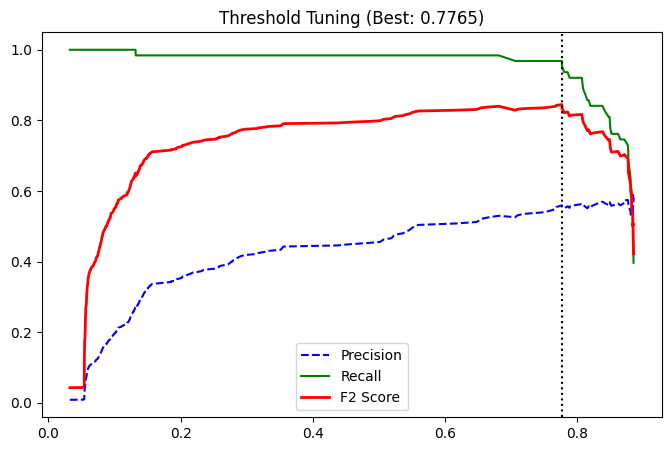

🔥 Optimal Critical Threshold: 0.7765


In [19]:
# ====================================================================
# 7. THRESHOLD TUNING (OPTIMIZE SAFETY)
# ====================================================================
log("🔧 Tuning Critical Threshold...")

def find_best_threshold(model, X, y_true):
    # เอาความน่าจะเป็นของ Class 2 (Critical)
    probs = model.predict_proba(X)[:, 2]
    
    # แปลง Label เป็น Binary (Critical=1, Others=0)
    y_bin = (y_true == 2).astype(int)
    
    # คำนวณ Curve
    precisions, recalls, thresholds = precision_recall_curve(y_bin, probs)
    
    # คำนวณ F2-Score (ให้ความสำคัญกับ Recall มากกว่า Precision 2 เท่า -> Safety First)
    f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-9)
    
    best_idx = np.argmax(f2_scores)
    best_thresh = thresholds[best_idx]
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.plot(thresholds, f2_scores[:-1], 'r-', linewidth=2, label='F2 Score')
    plt.axvline(best_thresh, color='black', linestyle=':')
    plt.title(f'Threshold Tuning (Best: {best_thresh:.4f})')
    plt.legend()
    plt.show()
    
    return best_thresh

# หา Threshold ที่ดีที่สุดจาก Validation Set
OPTIMAL_THRESHOLD = find_best_threshold(best_model, X_val_sel, y_val)
print(f"🔥 Optimal Critical Threshold: {OPTIMAL_THRESHOLD:.4f}")


========================= VALIDATION SET RESULTS =========================
Threshold Used : 0.7765
Accuracy       : 0.9399
F1-Weighted    : 0.9569

🛡️ SAFETY REPORT:
   - Missed Critical : 2 / 63
   ⚠ WARNING: Still missing some criticals.

Confusion Matrix:
[[6459  368   45]
 [   5   98    3]
 [   0    2   61]]
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97      6872
     Warning       0.21      0.92      0.34       106
    Critical       0.56      0.97      0.71        63

    accuracy                           0.94      7041
   macro avg       0.59      0.94      0.67      7041
weighted avg       0.98      0.94      0.96      7041


========================= TEST SET RESULTS =========================
Threshold Used : 0.7765
Accuracy       : 0.6966
F1-Weighted    : 0.7585

🛡️ SAFETY REPORT:
   - Missed Critical : 168 / 386
   ⚠ WARNING: Still missing some criticals.

Confusion Matrix:
[[3230 1474   52]
 [   6  479   10]
 [   7  161

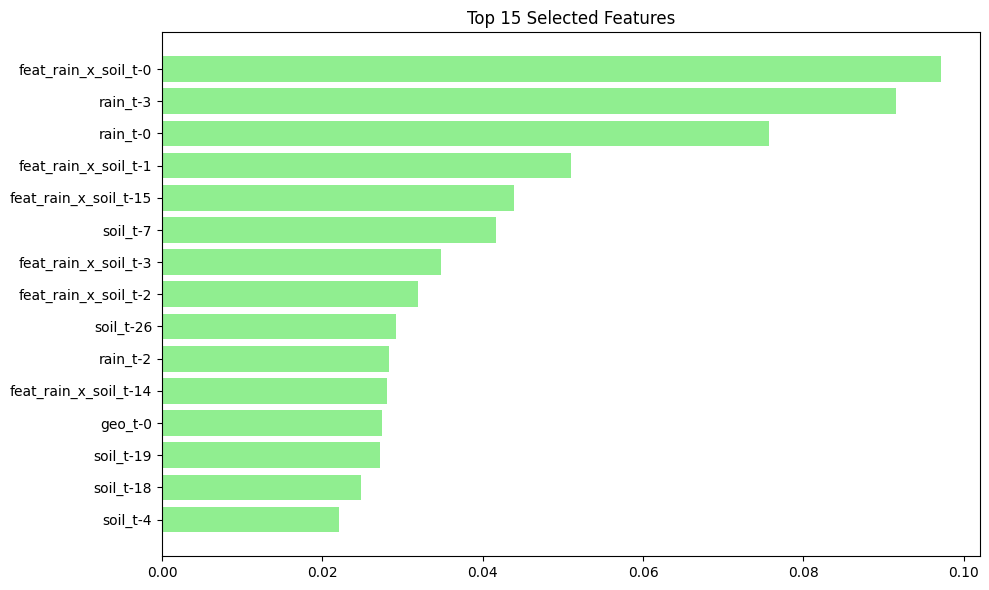

In [20]:
# ====================================================================
# 8. FINAL EVALUATION (CUSTOM PREDICT)
# ====================================================================
def custom_predict(model, X, threshold):
    """ทำนายโดยใช้ Threshold ที่จูนมาแล้ว"""
    probs = model.predict_proba(X)
    
    # Logic: ถ้า Prob Critical > Threshold -> ตอบ Critical
    # ถ้าไม่ -> แข่งกันระหว่าง Normal กับ Warning
    
    p_norm = probs[:, 0]
    p_warn = probs[:, 1]
    p_crit = probs[:, 2]
    
    preds = np.zeros(len(X), dtype=int)
    
    # 1. Critical Check
    crit_mask = p_crit >= threshold
    preds[crit_mask] = 2
    
    # 2. Warning vs Normal Check (สำหรับตัวที่ไม่ใช่ Critical)
    other_mask = ~crit_mask
    # ถ้า Warning มากกว่า Normal -> 1, else -> 0
    preds[other_mask] = np.where(p_warn[other_mask] > p_norm[other_mask], 1, 0)
    
    return preds

def evaluate_final(name, X, y):
    if len(X) == 0: return
    print(f"\n{'='*25} {name} RESULTS {'='*25}")
    
    # ใช้ Custom Predict
    y_pred = custom_predict(best_model, X, OPTIMAL_THRESHOLD)
    
    acc = accuracy_score(y, y_pred)
    f1_w = f1_score(y, y_pred, average='weighted')
    
    print(f"Threshold Used : {OPTIMAL_THRESHOLD:.4f}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"F1-Weighted    : {f1_w:.4f}")
    
    cm = confusion_matrix(y, y_pred)
    
    # Safety Check
    if cm.shape[0] > 2:
        missed_crit = cm[2, 0] + cm[2, 1]
        total_crit = np.sum(cm[2, :])
        print("\n🛡️ SAFETY REPORT:")
        print(f"   - Missed Critical : {missed_crit} / {total_crit}")
        if missed_crit == 0: print("   ✅ PERFECT SAFETY RECORD")
        else: print("   ⚠ WARNING: Still missing some criticals.")

    print("\nConfusion Matrix:")
    print(cm)
    print(classification_report(y, y_pred, target_names=['Normal', 'Warning', 'Critical']))

# วัดผลจริง
evaluate_final("VALIDATION SET", X_val_sel, y_val)
if len(X_test_sel) > 0:
    evaluate_final("TEST SET", X_test_sel, y_test_final)

# Feature Importance (เฉพาะฟีเจอร์ที่ผ่านเข้ารอบ)
imp = best_model.feature_importances_
indices = np.argsort(imp)[::-1][:15]
plt.figure(figsize=(10, 6))
plt.title("Top 15 Selected Features")
plt.barh(range(15), imp[indices], align="center", color='lightgreen')
plt.yticks(range(15), [selected_features[i] for i in indices])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()